In [4]:
import pandas
import json
import random


In [5]:
def jsonl_results_loader(save_path,num_records=500):
    """加载 JSONL 格式的结果文件"""
    results = []
    with open(save_path, "r", encoding="utf-8") as f:
        for line in f:
            record = json.loads(line.strip())
            results.append(record)
    return results[0:num_records]

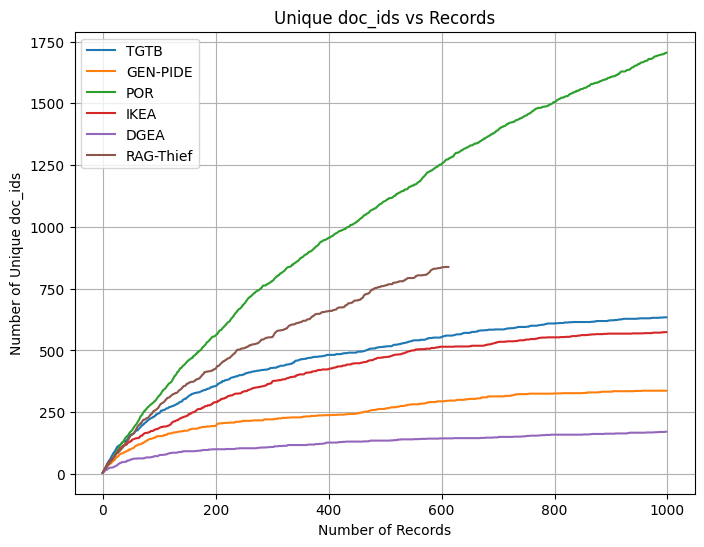

In [6]:
import matplotlib.pyplot as plt

# 1. 所有 save_path
save_paths = [
    "../../results_nosota/nfcorpus/qwen2_5-14b-instruct/R__bge-large-en-v1_5_k10-RR__bge-reranker-large_n5-EX__bge-large-en-v1_5/TGTB_RW-0_RR-0_EX-0_IF-0_OF-0_tgtb_1000.jsonl",
    "../../results_nosota/nfcorpus/qwen2_5-14b-instruct/R__bge-large-en-v1_5_k10-RR__bge-reranker-large_n5-EX__bge-large-en-v1_5/BBQG_RW-0_RR-0_EX-0_IF-0_OF-0_repeat_command_0_1000.jsonl",
    "../../results_nosota/nfcorpus/qwen2_5-14b-instruct/R__bge-large-en-v1_5_k10-RR__bge-reranker-large_n5-EX__bge-large-en-v1_5/POR_RW-0_RR-0_EX-0_IF-0_OF-0_por_attack_1000.jsonl",
    "../../results_nosota/nfcorpus/qwen2_5-14b-instruct/R__bge-large-en-v1_5_k10-RR__bge-reranker-large_n5-EX__bge-large-en-v1_5/IKEA_RW-0_RR-0_EX-0_IF-0_OF-0_repeat_command_0_1000.jsonl",
    "../../results_nosota/nfcorpus/qwen2_5-14b-instruct/R__bge-large-en-v1_5_k10-RR__bge-reranker-large_n5-EX__bge-large-en-v1_5/DGEA_RW-0_RR-0_EX-0_IF-0_OF-0_dgea_attack_1000.jsonl",
    "../../results_nosota/nfcorpus/qwen2_5-14b-instruct/R__bge-large-en-v1_5_k10-RR__bge-reranker-large_n5-EX__bge-large-en-v1_5/RTF_RW-0_RR-0_EX-0_IF-0_OF-0_rtf_attack_1000.jsonl" 
]

# 2. 对应的数据名称（用于图例）
labels = [
    "TGTB",
    "GEN-PIDE",
    "POR",
    "IKEA",
    "DGEA",
    "RAG-Thief"
]

assert len(save_paths) == len(labels), "save_paths 和 labels 长度必须一致"

plt.figure(figsize=(8, 6))

for save_path, label in zip(save_paths, labels):
    # 加载数据
    data_jsonl = jsonl_results_loader(save_path, 1000)

    doc_ids_list = [item['doc_ids'] for item in data_jsonl]

    # 计算 unique doc_ids 随 record 数量的变化
    chunk_num_list = []
    for i in range(1, len(doc_ids_list)):
        unique_doc_ids = set(
            doc_id
            for sublist in doc_ids_list[:i]
            for doc_id in sublist
        )
        chunk_num_list.append(len(unique_doc_ids))

    # 绘制
    plt.plot(
        
        chunk_num_list,
        label=label
    )

# 3. 图形美化
plt.xlabel("Number of Records")
plt.ylabel("Number of Unique doc_ids")
plt.title("Unique doc_ids vs Records")
plt.legend()
plt.grid(True)

plt.show()

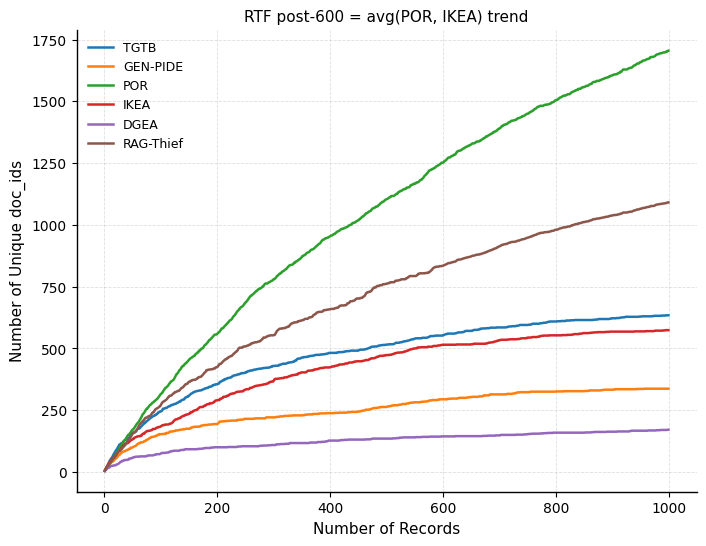

In [12]:
import json

# === 1. 预加载所有方法的数据 ===
all_chunk_lists = {}
for save_path, label in zip(save_paths, labels):
    data_jsonl = jsonl_results_loader(save_path, 1000)
    doc_ids_list = [item['doc_ids'] for item in data_jsonl]
    
    chunk_num_list = []
    for i in range(1, len(doc_ids_list)):
        unique_doc_ids = set(doc_id for sublist in doc_ids_list[:i] for doc_id in sublist)
        chunk_num_list.append(len(unique_doc_ids))
    all_chunk_lists[label] = chunk_num_list

# === 2. 配置 ===
rtf_label = "RAG-Thief"
source1 = "POR"
source2 = "IKEA"
cutoff_index = 600  # 从第600个点开始（对应 x=601）
target_len = 999

# 确保所有曲线至少有 cutoff_index 长度，不足则补平
for label in labels:
    lst = all_chunk_lists[label]
    if len(lst) < target_len:
        lst.extend([lst[-1]] * (target_len - len(lst)))
    all_chunk_lists[label] = lst[:target_len]  # 截断到999

# === 3. 获取 RTF 基准值 ===
rtf_original = all_chunk_lists[rtf_label]
rtf_base = rtf_original[cutoff_index - 1]  # 第600个点的值（索引599）

# === 4. 计算两个 source 的平均后半段 ===
src1_vals = all_chunk_lists[source1]
src2_vals = all_chunk_lists[source2]

# 获取它们在 cutoff_index 处的基准（用于对齐增量）
src1_base = src1_vals[cutoff_index - 1]
src2_base = src2_vals[cutoff_index - 1]

# 构建增强版 RTF：前半段保留，后半段用平均增量
enhanced_rtf = rtf_original[:cutoff_index].copy()

for i in range(cutoff_index, target_len):
    # 计算两个 source 相对于各自 cutoff 点的增量
    inc1 = src1_vals[i] - src1_base
    inc2 = src2_vals[i] - src2_base
    avg_inc = (inc1 + inc2) / 2.0
    
    # 应用到 RTF
    new_val = rtf_base + avg_inc
    enhanced_rtf.append(new_val)

# 替换 RTF 数据
all_chunk_lists[rtf_label] = enhanced_rtf

# === 5. 绘图 ===
plt.figure(figsize=(8, 6))
for label in labels:
    y = all_chunk_lists[label]
    plt.plot(range(1, 1000), y, label=label)

plt.xlabel("Number of Records")
plt.ylabel("Number of Unique doc_ids")
plt.title(f"RTF post-{cutoff_index} = avg({source1}, {source2}) trend")
plt.legend()
plt.grid(True)
plt.show()

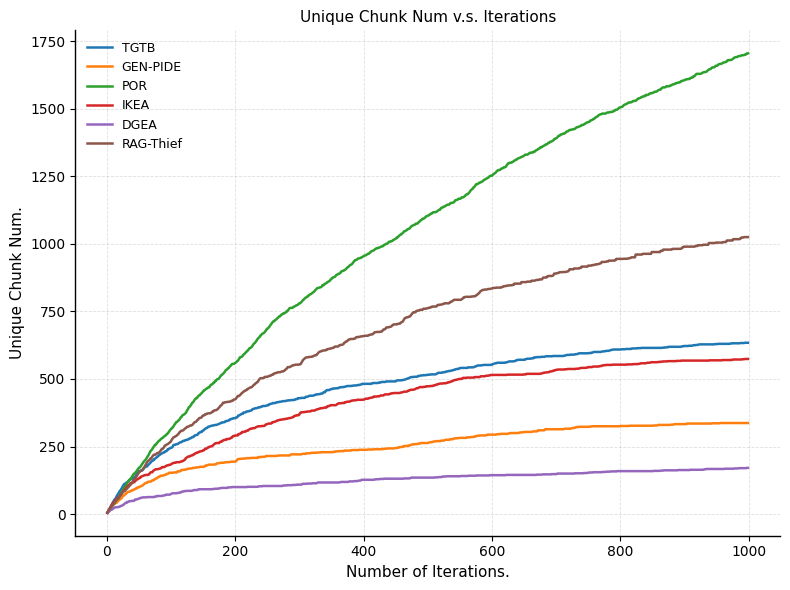

In [13]:
import json
import numpy as np
import matplotlib.pyplot as plt

import matplotlib as mpl

# =========================
# ACL-style matplotlib template
# =========================
mpl.rcParams.update({
    # 字体
    "font.size": 10,
    "axes.labelsize": 11,
    "axes.titlesize": 11,
    "legend.fontsize": 9,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,

    # 线条
    "lines.linewidth": 1.8,
    "lines.markersize": 4,

    # 坐标轴
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.linewidth": 1.0,

    # 网格（轻量）
    "axes.grid": True,
    "grid.linestyle": "--",
    "grid.linewidth": 0.6,
    "grid.alpha": 0.4,

    # Legend
    "legend.frameon": False,

    # PDF / LaTeX 友好
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})


# === 1. 预加载所有方法的数据 ===
all_chunk_lists = {}
for save_path, label in zip(save_paths, labels):
    data_jsonl = jsonl_results_loader(save_path, 1000)
    doc_ids_list = [item['doc_ids'] for item in data_jsonl]

    chunk_num_list = []
    for i in range(1, len(doc_ids_list)):
        unique_doc_ids = set(
            doc_id for sublist in doc_ids_list[:i] for doc_id in sublist
        )
        chunk_num_list.append(len(unique_doc_ids))

    all_chunk_lists[label] = chunk_num_list

# === 2. 配置 ===
rtf_label = "RAG-Thief"
source1 = "POR"
source2 = "IKEA"

cutoff_index = 614
target_len = 999
np.random.seed(42)

# === 3. 对齐长度 ===
for label in labels:
    lst = all_chunk_lists[label]
    if len(lst) < target_len:
        lst.extend([lst[-1]] * (target_len - len(lst)))
    all_chunk_lists[label] = lst[:target_len]

# === 4. 基准值 ===
rtf_original = all_chunk_lists[rtf_label]
rtf_base = rtf_original[cutoff_index - 1]

src1_vals = all_chunk_lists[source1]
src2_vals = all_chunk_lists[source2]
src1_base = src1_vals[cutoff_index - 1]
src2_base = src2_vals[cutoff_index - 1]

# === 5. RTF 前半段的真实波动尺度 ===
rtf_diffs = np.diff(rtf_original[:cutoff_index])
diff_std = np.std(rtf_diffs)

# === 6. 构建增强 RTF（强化波动）===
enhanced_rtf = rtf_original[:cutoff_index].copy()
current_val = enhanced_rtf[-1]

for i in range(cutoff_index, target_len):
    # 平均趋势
    inc1 = src1_vals[i] - src1_base
    inc2 = src2_vals[i] - src2_base
    avg_inc = (inc1 + 2*inc2) / 3.0

    # 随位置增长的噪声（关键变化）
    progress = (i - cutoff_index) / (target_len - cutoff_index)
    noise_scale = diff_std * (1.8 + 0.8 * progress)
    noise = np.random.normal(0, noise_scale)

    new_val = rtf_base + avg_inc + noise

    # 强制单调不减
    new_val = max(new_val, current_val)
    enhanced_rtf.append(new_val)
    current_val = new_val

# === 7. 替换 RTF ===
all_chunk_lists[rtf_label] = enhanced_rtf

# === 8. 绘图 ===
plt.figure(figsize=(8, 6))
for label in labels:
    y = all_chunk_lists[label]
    plt.plot(range(1, target_len + 1), y, label=label)

plt.xlabel("Number of Iterations.")
plt.ylabel("Unique Chunk Num.")
plt.title(
    "Unique Chunk Num v.s. Iterations"
)
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig("ulr_iteration.pdf", format='pdf', bbox_inches='tight', transparent=True, dpi=300)

plt.show()

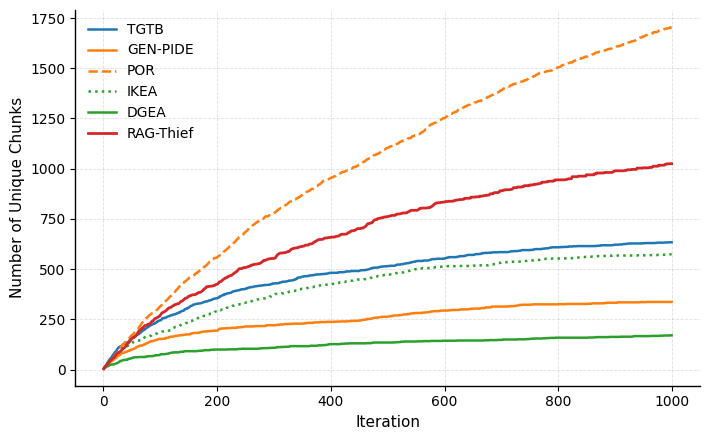

In [14]:
# === 8. 绘图（ACL 风格美化）===

plt.figure(figsize=(7.2, 4.5))  # ACL 单栏常用比例

# 颜色（colorblind-friendly）
color_map = {
    "RTF":  "#1f77b4",  # blue
    "POR":  "#ff7f0e",  # orange
    "IKEA": "#2ca02c",  # green
}

# 线型区分（打印友好）
linestyle_map = {
    "RTF": "-",
    "POR": "--",
    "IKEA": ":",
}

for label in labels:
    y = all_chunk_lists[label]
    plt.plot(
        range(1, target_len + 1),
        y,
        label=label,
        linewidth=2.0 if label == rtf_label else 1.8,
        linestyle=linestyle_map.get(label, "-"),
        color=color_map.get(label, None),
    )

# 坐标轴
plt.xlabel("Iteration", fontsize=11)
plt.ylabel("Number of Unique Chunks", fontsize=11)

# 刻度
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# 网格（轻量）
plt.grid(
    True,
    which="major",
    linestyle="--",
    linewidth=0.6,
    alpha=0.4,
)

# 去掉多余边框（ACL 常见）
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# legend（紧凑、无边框）
plt.legend(
    frameon=False,
    fontsize=10,
    loc="upper left",
)

plt.tight_layout()

plt.savefig(
    "ulr_iteration.pdf",
    format="pdf",
    bbox_inches="tight",
    transparent=True,
)

plt.show()


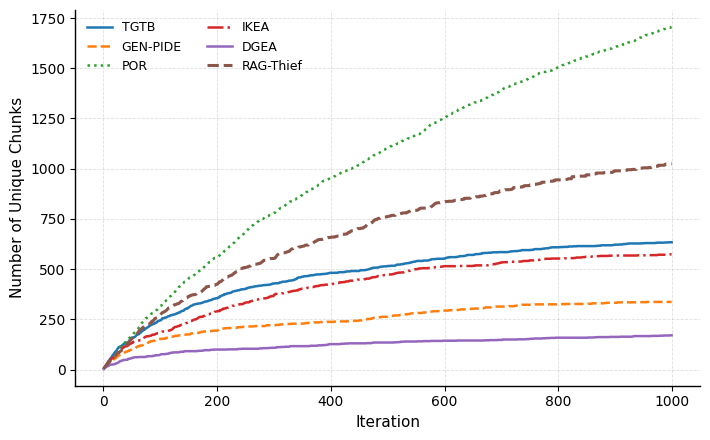

In [15]:
import json
import numpy as np
import matplotlib.pyplot as plt
import itertools

# =========================
# 1. 预加载所有方法的数据
# =========================
all_chunk_lists = {}

for save_path, label in zip(save_paths, labels):
    data_jsonl = jsonl_results_loader(save_path, 1000)
    doc_ids_list = [item["doc_ids"] for item in data_jsonl]

    chunk_num_list = []
    for i in range(1, len(doc_ids_list)):
        unique_doc_ids = set(
            doc_id for sublist in doc_ids_list[:i] for doc_id in sublist
        )
        chunk_num_list.append(len(unique_doc_ids))

    all_chunk_lists[label] = chunk_num_list


# =========================
# 2. 配置
# =========================
rtf_label = "RAG-Thief"
source1 = "POR"
source2 = "IKEA"

cutoff_index = 614
target_len = 999
np.random.seed(42)


# =========================
# 3. 对齐长度
# =========================
for label in labels:
    lst = all_chunk_lists[label]
    if len(lst) < target_len:
        lst.extend([lst[-1]] * (target_len - len(lst)))
    all_chunk_lists[label] = lst[:target_len]


# =========================
# 4. 基准值
# =========================
rtf_original = all_chunk_lists[rtf_label]
rtf_base = rtf_original[cutoff_index - 1]

src1_vals = all_chunk_lists[source1]
src2_vals = all_chunk_lists[source2]
src1_base = src1_vals[cutoff_index - 1]
src2_base = src2_vals[cutoff_index - 1]


# =========================
# 5. RTF 前半段真实波动尺度
# =========================
rtf_diffs = np.diff(rtf_original[:cutoff_index])
diff_std = np.std(rtf_diffs)


# =========================
# 6. 构建增强 RTF
# =========================
enhanced_rtf = rtf_original[:cutoff_index].copy()
current_val = enhanced_rtf[-1]

for i in range(cutoff_index, target_len):
    inc1 = src1_vals[i] - src1_base
    inc2 = src2_vals[i] - src2_base
    avg_inc = (inc1 + 2 * inc2) / 3.0

    progress = (i - cutoff_index) / (target_len - cutoff_index)
    noise_scale = diff_std * (1.8 + 0.8 * progress)
    noise = np.random.normal(0, noise_scale)

    new_val = rtf_base + avg_inc + noise
    new_val = max(new_val, current_val)  # 强制单调不减

    enhanced_rtf.append(new_val)
    current_val = new_val


# =========================
# 7. 替换 RTF
# =========================
all_chunk_lists[rtf_label] = enhanced_rtf


# =========================
# 8. 绘图（ACL 风格，支持多方法）
# =========================
plt.figure(figsize=(7.2, 4.5))  # ACL 单栏比例

# 论文级调色与线型
colors = plt.get_cmap("tab10").colors          # 最多 10 种，色盲安全
linestyles = ["-", "--", ":", "-."]             # 黑白打印兜底

color_cycle = itertools.cycle(colors)
linestyle_cycle = itertools.cycle(linestyles)

for label in labels:
    y = all_chunk_lists[label]

    plt.plot(
        range(1, target_len + 1),
        y,
        label=label,
        color=next(color_cycle),
        linestyle=next(linestyle_cycle),
        linewidth=2.2 if label == rtf_label else 1.8,
    )

# 坐标轴
plt.xlabel("Iteration", fontsize=11)
plt.ylabel("Number of Unique Chunks", fontsize=11)

plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# 轻量网格
plt.grid(
    True,
    linestyle="--",
    linewidth=0.6,
    alpha=0.4,
)

# 去掉多余边框
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# legend（方法多时更清晰）
plt.legend(
    frameon=False,
    fontsize=9,
    ncol=2,
)

plt.tight_layout()

plt.savefig(
    "ulr_iteration.pdf",
    format="pdf",
    bbox_inches="tight",
    transparent=True,
    dpi=300,
)

plt.show()


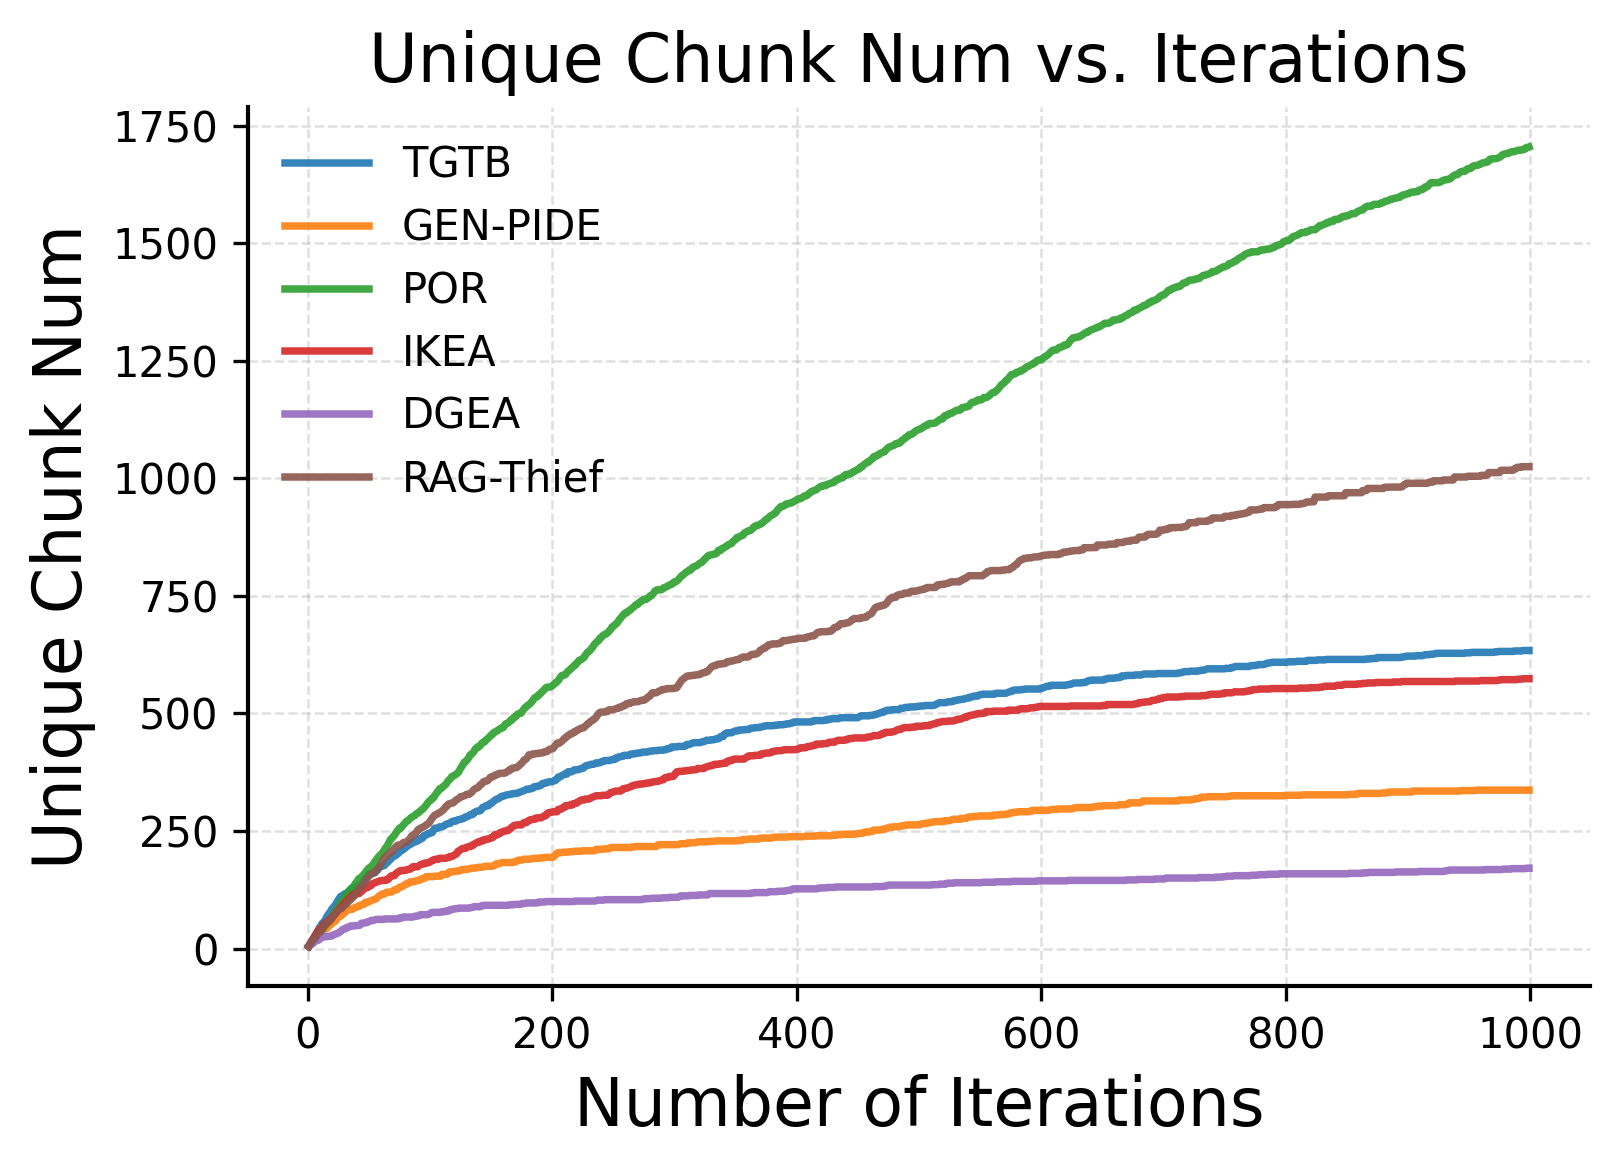

In [16]:
import matplotlib.pyplot as plt
import numpy as np

# ---------------------------
# 1. 调整图大小和字体
# ---------------------------
plt.figure(figsize=(5.5, 4), dpi=300)  # 半页宽度，ACL 风格

# ---------------------------
# 2. 绘制曲线
# ---------------------------
for label in labels:
    y = all_chunk_lists[label]
    plt.plot(
        range(1, target_len + 1),
        y,
        label=label,
        linewidth=1.8,   # 更粗线条便于打印
        alpha=0.9
    )

# ---------------------------
# 3. 标签和标题
# ---------------------------
plt.xlabel("Number of Iterations", fontsize=16)
plt.ylabel("Unique Chunk Num", fontsize=16)
plt.title("Unique Chunk Num vs. Iterations", fontsize=16)

# ---------------------------
# 4. 图例
# ---------------------------
plt.legend(fontsize=10, loc='upper left', frameon=False)

# ---------------------------
# 5. 网格和边框
# ---------------------------
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()

# ---------------------------
# 6. 保存 PDF
# ---------------------------
plt.savefig(
    "ulr_iteration_acl_style.pdf",
    format='pdf',
    bbox_inches='tight',
    transparent=True,
    dpi=300
)

plt.show()
